# Singular Spectrum Analysis (SSA) Forecast Evaluation

This notebook splits `forecast_data_365.csv` into 70% training and 30% testing data. It trains an SSA model on the training set, forecasts the testing period, evaluates it using MAE, RMSE, and MAPE, and plots the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv('forecast_data_365.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 70-30 Split
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Total data points: {len(df)}")
print(f"Training data points: {len(train_df)}")
print(f"Testing data points: {len(test_df)}")


Total data points: 365
Training data points: 255
Testing data points: 110


In [2]:
# SSA Class Definition
class SSA:
    def __init__(self, tseries, L):
        # Time series and Window Length L
        self.tseries = np.array(tseries)
        self.N = len(self.tseries)
        self.L = L
        self.K = self.N - self.L + 1
        
        # Step 1: Embedding (Trajectory Matrix)
        self.X = np.column_stack([self.tseries[i:i+self.L] for i in range(self.K)])
        
        # Step 2: Singular Value Decomposition (SVD)
        self.U, self.Sigma, self.VT = np.linalg.svd(self.X, full_matrices=False)
        self.d = np.linalg.matrix_rank(self.X)

    def reconstruct(self, components):
        if isinstance(components, int): components = [components]
        
        X_elem = np.zeros_like(self.X, dtype=float)
        for i in components:
            if i < len(self.Sigma):
                X_elem += self.Sigma[i] * np.outer(self.U[:, i], self.VT[i, :])
            
        rcs = np.zeros(self.N)
        counts = np.zeros(self.N)
        for i in range(self.L):
            for j in range(self.K):
                rcs[i+j] += X_elem[i, j]
                counts[i+j] += 1
        return rcs / counts

    def forecast(self, components, steps=30):
        if isinstance(components, int): components = [components]
        components = [c for c in components if c < len(self.Sigma)]
        
        U_m = self.U[:-1, components] # L-1 x r
        pi_m = self.U[-1, components] # r
        
        v_sq = np.sum(pi_m**2)
        if v_sq >= 1.0:
            print("Warning: LRF not stable for chosen components.")
            return np.zeros(steps)
            
        R = np.zeros(self.L - 1)
        for i, c in enumerate(components):
            R += pi_m[i] * U_m[:, i]
        R = R / (1 - v_sq)
        
        rec = self.reconstruct(components)
        predictions = list(rec)
        
        for _ in range(steps):
            last_window = np.array(predictions[-(self.L-1):])
            next_val = np.dot(R, last_window)
            predictions.append(next_val)
            
        return np.array(predictions[-steps:])


In [3]:
# Train SSA and Forecast
L = 30 # Window length
steps_to_forecast = len(test_df)

ssa = SSA(train_df['Price'], L=L)

# We assume component 0 as Trend, 1-3 as Seasonality (similar to daily.xlsx analysis)
components_to_forecast = [0, 1, 2, 3]
forecast_values = ssa.forecast(components_to_forecast, steps=steps_to_forecast)

test_df = test_df.copy()
test_df['Forecast'] = forecast_values


In [4]:
# Evaluation Metrics
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mae = mean_absolute_error(test_df['Price'], test_df['Forecast'])
rmse = np.sqrt(mean_squared_error(test_df['Price'], test_df['Forecast']))
mape = mean_absolute_percentage_error(test_df['Price'], test_df['Forecast'])

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")


Mean Absolute Error (MAE): 19.7672
Root Mean Squared Error (RMSE): 22.9176
Mean Absolute Percentage Error (MAPE): 7.2069%


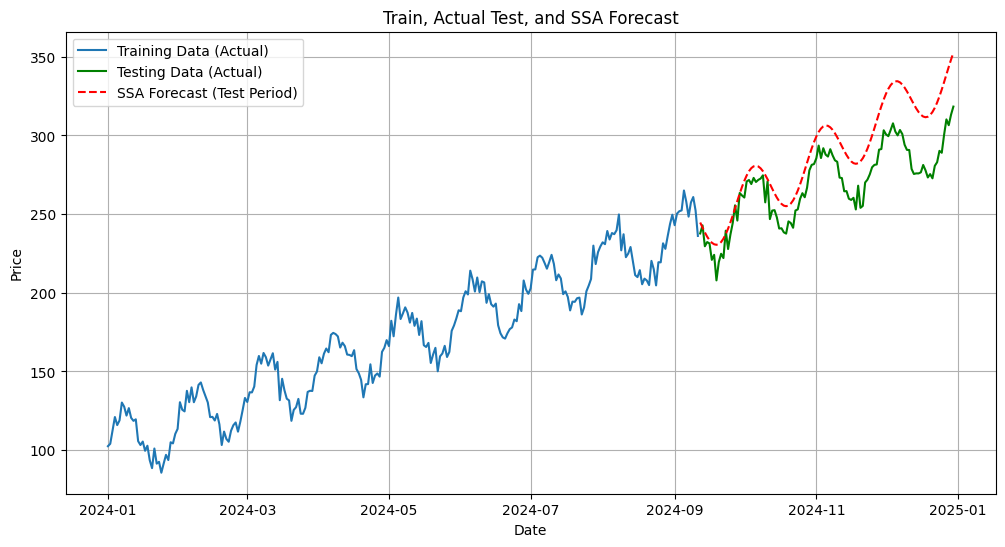

In [5]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_df['Date'], train_df['Price'], label='Training Data (Actual)')
plt.plot(test_df['Date'], test_df['Price'], label='Testing Data (Actual)', color='green')
plt.plot(test_df['Date'], test_df['Forecast'], label='SSA Forecast (Test Period)', color='red', linestyle='--')

plt.title('Train, Actual Test, and SSA Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
